## Context

### After watching Somm (a documentary on master sommeliers) I wondered how I could create a predictive model to identify wines through blind tasting like a master sommelier would. The first step in this journey was gathering some data to train a model. I plan to use deep learning to predict the wine variety using words in the description/review. The model still won't be able to taste the wine, but theoretically it could identify the wine based on a description that a sommelier could give. If anyone has any ideas on how to accomplish this, please post them!


## Description of each data

* Country - The country that the wine is from

* designation - The vineyard within the winery where the grapes that made the wine are from

* points - The number of points WineEnthusiast rated the wine on a scale of 1-100 (though they say they only post reviews for wines that score &gt;=80)

* price - The cost for a bottle of the wine

* province - The province or state that the wine is from

* region_1 - The wine growing area in a province or state (ie Napa)

* region_2 - Sometimes there are more specific regions specified within a wine growing area (ie Rutherford inside the Napa Valley), but this value can sometimes be blank

* taster_name and taster twitter handle


In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('winemag-data-130k-v2.csv', index_col=0) # Previously I saw that there's a unamed col, so we drop data from df

In [3]:
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


## To start our analyse, first we msut know what kinda data we're dealing with

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                129908 non-null  object 
 1   description            129971 non-null  object 
 2   designation            92506 non-null   object 
 3   points                 129971 non-null  int64  
 4   price                  120975 non-null  float64
 5   province               129908 non-null  object 
 6   region_1               108724 non-null  object 
 7   region_2               50511 non-null   object 
 8   taster_name            103727 non-null  object 
 9   taster_twitter_handle  98758 non-null   object 
 10  title                  129971 non-null  object 
 11  variety                129970 non-null  object 
 12  winery                 129971 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 13.9+ MB


### Unfortunately we have a LOT of missing data, but that's an usual day as analist

In [5]:
# 1. Calculate null sum
count_null = df.isnull().sum()

# 2. Transform into a DataFrame and rename columns
df_nulls = count_null.reset_index()
df_nulls.columns = ['Column', 'Null_Count']

# 3. Add percentage column for quick analysis
df_nulls['Percentage (%)'] = (df_nulls['Null_Count'] / len(df)) * 100

# Sort by most nulls
df_nulls = df_nulls.sort_values(by='Null_Count', ascending=False)

df_nulls

,Column,Null_Count,Percentage (%)
7,region_2,79460,61.136715
2,designation,37465,28.825661
9,taster_twitter_handle,31213,24.015357
8,taster_name,26244,20.192197
6,region_1,21247,16.347493
4,price,8996,6.921544
5,province,63,0.048472
0,country,63,0.048472
11,variety,1,0.000769
3,points,0,0.000000


### We got some good news here

1. Based on description, region_2 is not a big problem of havind many null data.

2. The lack of almost 7% of data pricing wine is a little loss, but it won't cause a big truble.

3. designation could be, but as our data is really big, that may compensate it.

4. 0.00007% null in variety is excellent for our Deep Learning as it's description 0% and points 0%

# How many kinda grapes have we?

In [6]:
grapes_variety = df.variety.value_counts()
grapes_percentage = df.variety.value_counts(normalize=True)*100

df_distribuction_grapes = pd.DataFrame({
    'Count':grapes_variety,
    'Percentage (%)':grapes_percentage
})
df_distribuction_grapes

,Count,Percentage (%)
variety,,
Pinot Noir,13272,10.211587
Chardonnay,11753,9.042856
Cabernet Sauvignon,9472,7.287836
Red Blend,8946,6.883127
Bordeaux-style Red Blend,6915,5.320459
...,...,...
Picapoll,1,0.000769
Blauburger,1,0.000769
Tinta Madeira,1,0.000769


In [7]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import layers

# --- PRE-CLEANING (Important to avoid conversion errors) ---
# Ensure no null values exist and force everything to string type
df['description'] = df['description'].fillna('').astype(str)

# 1. Preparing Labels (Grape Varieties)
le = LabelEncoder()
y = le.fit_transform(df['variety']) 
num_classes = len(le.classes_)

# 2. Splitting the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    df['description'], y, test_size=0.2, random_state=42
)

# --- DTYPE CORRECTION: Converting to String Tensors ---
# This ensures TensorFlow recognizes the input as a valid string array
X_train_tensor = tf.convert_to_tensor(X_train.values, dtype=tf.string)
X_test_tensor = tf.convert_to_tensor(X_test.values, dtype=tf.string)

# 3. Text Vectorization Layer (Converts words to integers)
max_tokens = 10000 
sequence_length = 100 

vectorize_layer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length
)
# Adapt the layer using the training string tensor
vectorize_layer.adapt(X_train_tensor)

# 4. Neural Network Architecture (CPU-friendly for i5 processors)
model = tf.keras.Sequential([
    vectorize_layer,
    layers.Embedding(max_tokens, 64, mask_zero=True),
    layers.GlobalAveragePooling1D(), # Reduces complexity for faster CPU training
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # Helps prevent overfitting
    layers.Dense(num_classes, activation='softmax') # Final decision layer
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Training (Using the corrected tensors) - Capturing history for visualization
history = model.fit(
    X_train_tensor, 
    y_train, 
    epochs=10, 
    validation_data=(X_test_tensor, y_test), 
    batch_size=32
)

E0000 00:00:1777305135.229760    2867 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.2561 - loss: 3.2367 - val_accuracy: 0.3835 - val_loss: 2.5268
Epoch 2/10
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.4403 - loss: 2.3051 - val_accuracy: 0.4900 - val_loss: 2.1023
Epoch 3/10
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.5218 - loss: 1.9528 - val_accuracy: 0.5379 - val_loss: 1.8940
Epoch 4/10
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.5667 - loss: 1.7521 - val_accuracy: 0.5589 - val_loss: 1.8068
Epoch 5/10
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.5949 - loss: 1.6209 - val_accuracy: 0.5733 - val_loss: 1.7555
Epoch 6/10
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.6145 - loss: 1.5232 - val_accuracy: 0.5815 - val_loss: 1.7320
Epoch 7/10
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - accuracy: 0.6297 - loss: 1.4470 - val_accuracy: 0.5854 - val_loss: 1.7271
Epoch 8/10
3250/3250 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.6410 -

## Rating the Prediction Model

Now we're gonna rate the peformance of model in test data and make predictions on new wine descriptions

In [8]:
# Rating model
print("=" * 60)
print("RATING MODEL")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(X_test_tensor, y_test, verbose=0)
print(f"\nLoss in test: {test_loss:.4f}")
print(f"Accuracy on test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make predictions
y_pred_probs = model.predict(X_test_tensor[:100], verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Some examples to share
print("\n" + "=" * 60)
print("EXAMPLES OF PREDICTIONS")
print("=" * 60)

for i in range(5):
    predicted_variety = le.inverse_transform([y_pred[i]])[0]
    actual_variety = le.inverse_transform([y_test[i]])[0]
    confidence = y_pred_probs[i][y_pred[i]]
    
    print(f"\n--- Wine {i+1} ---")
    print(f"Description: {X_test.iloc[i][:130]}...")
    print(f"Variety Prediceted: {predicted_variety} (Confidence: {confidence*100:.2f}%)")
    print(f"Real Variety: {actual_variety}")
    print(f":Success {'✓' if predicted_variety == actual_variety else '✗'}")

RATING MODEL

Loss in test: 1.7224
Accuracy on test: 0.5972 (59.72%)

EXAMPLES OF PREDICTIONS

--- Wine 1 ---
Description: Possibly a little sweet, this is a soft, easygoing Chardonnay marked by clean, modest pear and melon flavors....
Variety Prediceted: Chardonnay (Confidence: 99.81%)
Real Variety: Chardonnay
:Success ✓

--- Wine 2 ---
Description: A soft, almost off dry wine that is full in the mouth. It has caramel and spice flavors as well as light acidity. The wine feels w...
Variety Prediceted: Rosé (Confidence: 89.06%)
Real Variety: Rosé
:Success ✓

--- Wine 3 ---
Description: Generic white-fruit aromas of peach and apple are slightly pithy. This feels good but innocuous, while flavors of apple and stone ...
Variety Prediceted: Chardonnay (Confidence: 37.51%)
Real Variety: Verdejo-Viura
:Success ✗

--- Wine 4 ---
Description: This is the winery's best Nebula in years. While it's still a little on the soft, sweet side, the cool vintage has resonated in th...
Variety Prediceted: 

## Prediciton on new descriptions

Now you can use the model to indentify wine variability based on its description, as Sommelier would do!

In [9]:
# Function to make predictions with new descriptions
def predict_wine_variety(description):
    """
    Predicts the wine variety based on a description.
    
    Args:
        description (str): Wine description (as a sommelier would provide).
    
    Returns:
        dict: Predicted variety and top 5 varieties with confidence scores.
    """
    # Convert input string to tensor
    input_tensor = tf.convert_to_tensor([description], dtype=tf.string)
    
    # Run prediction
    predictions = model.predict(input_tensor, verbose=0)[0]
    
    # Get top 5 indices
    top_5_idx = np.argsort(predictions)[-5:][::-1]
    
    result = {
        'predicted_variety': le.inverse_transform([np.argmax(predictions)])[0],
        'confidence': f"{np.max(predictions)*100:.2f}%",
        'top_5': []
    }
    
    for idx in top_5_idx:
        variety = le.inverse_transform([idx])[0]
        confidence = f"{predictions[idx]*100:.2f}%"
        result['top_5'].append({'variety': variety, 'confidence': confidence})
    
    return result

# Prediction Examples
test_descriptions = [
    "Rich and complex with notes of dark cherry, blackberry and subtle oak. Full-bodied with smooth tannins.",
    "Light and fruity with aromas of citrus, green apple and tropical fruits. Crisp acidity.",
    "Bold wine with plum, prune and spice flavors. Velvety texture with hints of vanilla."
]

print("=" * 80)
print("DEMONSTRATION: WINE IDENTIFICATION THROUGH DESCRIPTION")
print("(As a Sommelier would do in a Blind Tasting)")
print("=" * 80)

for i, desc in enumerate(test_descriptions, 1):
    result = predict_wine_variety(desc)
    print(f"\n{'='*80}")
    print(f"Description {i}: {desc}")
    print(f"\n✓ Predicted Variety: {result['predicted_variety']} ({result['confidence']} confidence)")
    print(f"\nTop 5 Varieties:")
    for j, item in enumerate(result['top_5'], 1):
        print(f"  {j}. {item['variety']:30} - {item['confidence']:>8} confidence")

DEMONSTRATION: WINE IDENTIFICATION THROUGH DESCRIPTION
(As a Sommelier would do in a Blind Tasting)

Description 1: Rich and complex with notes of dark cherry, blackberry and subtle oak. Full-bodied with smooth tannins.

✓ Predicted Variety: Cabernet Sauvignon (27.55% confidence)

Top 5 Varieties:
  1. Cabernet Sauvignon             -   27.55% confidence
  2. Merlot                         -   12.09% confidence
  3. Petite Sirah                   -   10.51% confidence
  4. Barbera                        -    7.08% confidence
  5. Pinot Noir                     -    5.66% confidence

Description 2: Light and fruity with aromas of citrus, green apple and tropical fruits. Crisp acidity.

✓ Predicted Variety: Sauvignon Blanc (32.24% confidence)

Top 5 Varieties:
  1. Sauvignon Blanc                -   32.24% confidence
  2. Chardonnay                     -   30.79% confidence
  3. Verdejo                        -   10.62% confidence
  4. Albariño                       -    5.98% confidence

## Analyse of Performance per Variability

We're gonna check in which performance the model identifies each variety

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions in all test set
y_pred_full = np.argmax(model.predict(X_test_tensor, verbose=0), axis=1)

# Classification report
print("\n" + "=" * 80)
print("RELATÓRIO DETALHADO POR VARIEDADE")
print("=" * 80)

# Obtain top 10 varieties presents on data test
unique_classes = np.unique(y_test)[:10]
target_names = le.inverse_transform(unique_classes)

print(classification_report(y_test, y_pred_full, 
                          labels=unique_classes,
                          target_names=target_names,
                          zero_division=0))

print("\n" + "=" * 80)
print(f"Summary: The model reached {test_accuracy*100:.2f}% of accuracy in identify")
print("Variety of wine based in only description of blind tips!")
print("=" * 80)


RELATÓRIO DETALHADO POR VARIEDADE
              precision    recall  f1-score   support

    Abouriou       0.00      0.00      0.00         2
 Agiorgitiko       0.67      0.20      0.31        10
   Aglianico       0.68      0.35      0.46        74
       Airen       0.00      0.00      0.00         2
      Albana       0.00      0.00      0.00         5
   Albanello       0.00      0.00      0.00         1
    Albariño       0.55      0.43      0.48        94
    Aleatico       0.00      0.00      0.00         1
 Alfrocheiro       0.00      0.00      0.00         3
    Alicante       0.00      0.00      0.00         1

   micro avg       0.60      0.35      0.44       193
   macro avg       0.19      0.10      0.13       193
weighted avg       0.56      0.35      0.43       193


Summary: The model reached 59.72% of accuracy in identify
Variety of wine based in only description of blind tips!


## Visualizing Learning Model

Let's see how model learned during training with Seaborn

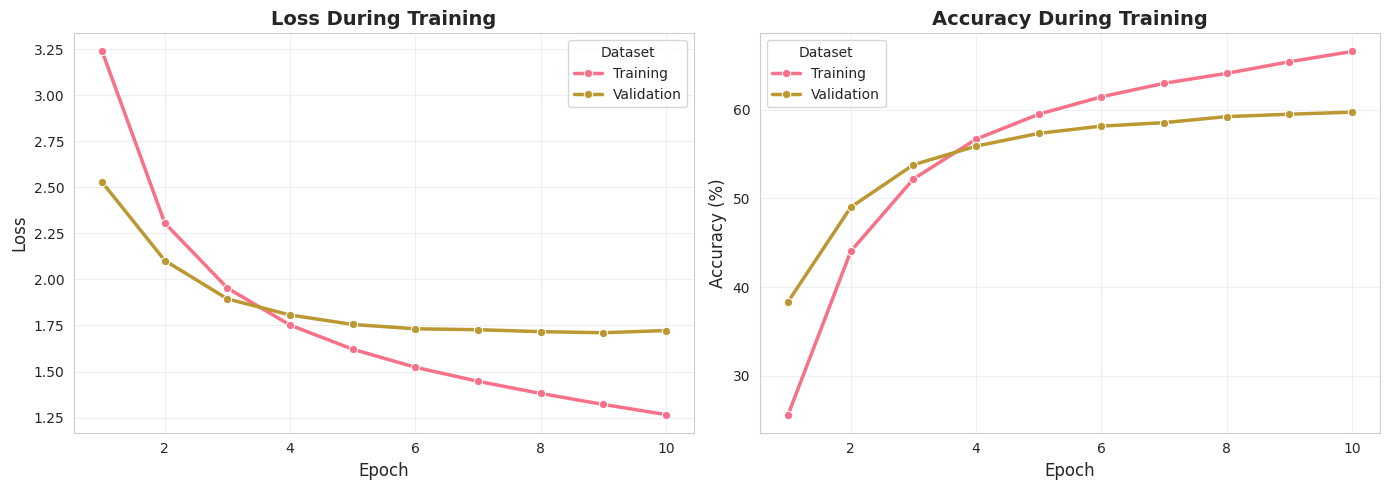


TRAINING SUMMARY

Initial Loss:      3.2367
Final Loss:        1.2665
Reduction:         60.87%

Initial Accuracy:  25.61%
Final Accuracy:    66.56%
Improvement:       40.95%

Val. Accuracy:     59.72%


In [11]:
# Set Seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Convert history to DataFrame for Seaborn usage
history_df = pd.DataFrame(history.history)
history_df['epoch'] = range(1, len(history_df) + 1)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['loss'],
    'Type': 'Training'
})
val_loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['val_loss'],
    'Type': 'Validation'
})
combined_loss = pd.concat([loss_data, val_loss_data], ignore_index=True)

sns.lineplot(data=combined_loss, x='Epoch', y='Loss', hue='Type', 
             ax=axes[0], linewidth=2.5, marker='o', markersize=6)
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Dataset')

# Plot 2: Accuracy
acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['accuracy'] * 100,
    'Type': 'Training'
})
val_acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['val_accuracy'] * 100,
    'Type': 'Validation'
})
combined_acc = pd.concat([acc_data, val_acc_data], ignore_index=True)

sns.lineplot(data=combined_acc, x='Epoch', y='Accuracy', hue='Type', 
             ax=axes[1], linewidth=2.5, marker='o', markersize=6)
axes[1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Dataset')

plt.tight_layout()
plt.show()

# Metrics Summary
print("\n" + "=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print(f"\nInitial Loss:      {history.history['loss'][0]:.4f}")
print(f"Final Loss:        {history.history['loss'][-1]:.4f}")
print(f"Reduction:         {((history.history['loss'][0] - history.history['loss'][-1]) / history.history['loss'][0] * 100):.2f}%")

print(f"\nInitial Accuracy:  {history.history['accuracy'][0]*100:.2f}%")
print(f"Final Accuracy:    {history.history['accuracy'][-1]*100:.2f}%")
print(f"Improvement:       {(history.history['accuracy'][-1] - history.history['accuracy'][0])*100:.2f}%")

print(f"\nVal. Accuracy:     {history.history['val_accuracy'][-1]*100:.2f}%")
print("=" * 80)

## Análise Detalhada com Visualizações Adicionais

Heatmap mostrando as métricas de desempenho ao longo das épocas

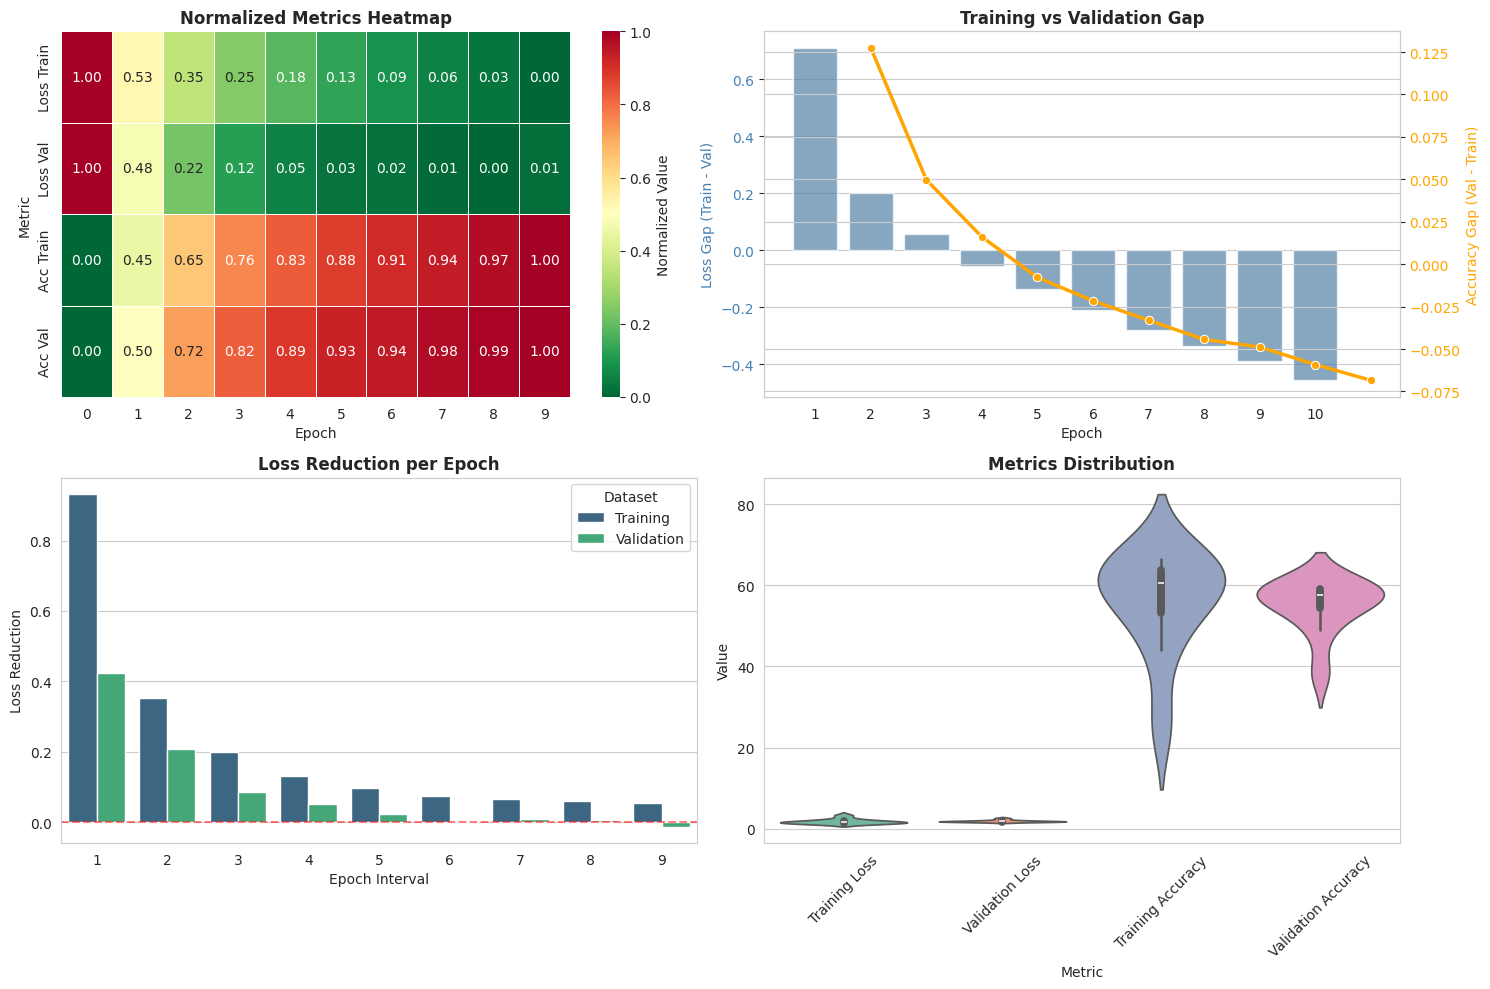


OVERFITTING ANALYSIS

Average Loss Gap (Train - Val): -0.0887
Final Loss Gap: -0.4559

Average Accuracy Gap (Val - Train): -0.90%
Final Accuracy Gap: -6.84%

 Well-balanced model (Low overfitting)


In [12]:
# Create figure with additional visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Metrics Heatmap
metrics_data = history_df[['loss', 'val_loss', 'accuracy', 'val_accuracy']].copy()
metrics_data.columns = ['Loss Train', 'Loss Val', 'Acc Train', 'Acc Val']
# Normalize for better visualization
metrics_normalized = (metrics_data - metrics_data.min()) / (metrics_data.max() - metrics_data.min())

sns.heatmap(metrics_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Normalized Value'}, ax=axes[0, 0], linewidths=0.5)
axes[0, 0].set_title('Normalized Metrics Heatmap', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Metric')

# Plot 2: Training vs Validation Gap
gap_loss = history_df['loss'] - history_df['val_loss']
gap_acc = history_df['val_accuracy'] - history_df['accuracy']

gap_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss Gap': gap_loss,
    'Acc Gap': gap_acc
})

ax2_twin = axes[0, 1].twinx()
sns.barplot(data=gap_data, x='Epoch', y='Loss Gap', ax=axes[0, 1], color='steelblue', alpha=0.7)
sns.lineplot(data=gap_data, x='Epoch', y='Acc Gap', ax=ax2_twin, color='orange', linewidth=2.5, marker='o')

axes[0, 1].set_title('Training vs Validation Gap', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Loss Gap (Train - Val)', color='steelblue', fontsize=10)
ax2_twin.set_ylabel('Accuracy Gap (Val - Train)', color='orange', fontsize=10)
axes[0, 1].tick_params(axis='y', labelcolor='steelblue')
ax2_twin.tick_params(axis='y', labelcolor='orange')

# Plot 3: Loss Reduction Speed
train_loss_diff = -np.diff(history_df['loss'])
val_loss_diff = -np.diff(history_df['val_loss'])
epochs = list(range(1, len(train_loss_diff) + 1))

# 2. Creating a DataFrame "long-format" for Seaborn
diff_data = pd.DataFrame({
    'Epoch_Interval': epochs * 2,
    'Loss_Reduction': np.concatenate([train_loss_diff, val_loss_diff]),
    'Dataset': ['Training'] * len(train_loss_diff) + ['Validation'] * len(val_loss_diff)
})

sns.barplot(
    data=diff_data, 
    x='Epoch_Interval', 
    y='Loss_Reduction', 
    hue='Dataset', 
    ax=axes[1, 0], 
    palette='viridis'
)

axes[1, 0].set_title('Loss Reduction per Epoch', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch Interval')
axes[1, 0].set_ylabel('Loss Reduction')
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# Plot 4: Metric Distribution
metrics_dist = pd.DataFrame({
    'Training Loss': history_df['loss'],
    'Validation Loss': history_df['val_loss'],
    'Training Accuracy': history_df['accuracy'] * 100,
    'Validation Accuracy': history_df['val_accuracy'] * 100
})

metrics_melted = metrics_dist.reset_index(drop=True).reset_index().melt(
    id_vars='index', 
    var_name='Metric', 
    value_name='Value'
)

sns.violinplot(
    data=metrics_melted, 
    x='Metric', 
    y='Value', 
    hue='Metric', 
    ax=axes[1, 1], 
    palette='Set2', 
    legend=False
)

axes[1, 1].set_title('Metrics Distribution', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Overfitting Analysis Summary
print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS")
print("=" * 80)
print(f"\nAverage Loss Gap (Train - Val): {gap_loss.mean():.4f}")
print(f"Final Loss Gap: {gap_loss.iloc[-1]:.4f}")
print(f"\nAverage Accuracy Gap (Val - Train): {gap_acc.mean()*100:.2f}%")
print(f"Final Accuracy Gap: {gap_acc.iloc[-1]*100:.2f}%")

if gap_loss.iloc[-1] < 0.1:
    print("\n Well-balanced model (Low overfitting)")
elif gap_loss.iloc[-1] < 0.3:
    print("\n Slight overfitting detected")
else:
    print("\n Significant overfitting detected")
print("=" * 80)